# Multi-Asset Donchian Ensemble



In [1]:
import requests, zipfile, io, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

HOURS_PER_YEAR = 365 * 24

## Download helper (Binance monthly klines) — same as your notebook

In [2]:
def download_binance_monthly_klines(symbol="BTCUSDT", interval="1h",
    start_year=2017, start_month=8, end_year=2026, end_month=5, save_csv=False):
    all_data = []
    months = pd.period_range(start=f"{start_year}-{start_month:02d}",
                             end=f"{end_year}-{end_month:02d}", freq="M")
    for month in months:
        ym = str(month)
        url = (f"https://data.binance.vision/data/spot/monthly/klines/"
               f"{symbol}/{interval}/{symbol}-{interval}-{ym}.zip")
        response = requests.get(url, timeout=30)
        if response.status_code == 404:
            continue
        response.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            temp = pd.read_csv(z.open(z.namelist()[0]), header=None)
            temp.columns = ["open_time","open","high","low","close","volume",
                            "close_time","quote_asset_volume","number_of_trades",
                            "taker_buy_base_volume","taker_buy_quote_volume","ignore"]
            all_data.append(temp)
        time.sleep(0.05)
    if not all_data:
        raise ValueError(f"No data for {symbol}")
    df = pd.concat(all_data, ignore_index=True)
    # Binance switched kline timestamps from milliseconds to MICROSECONDS in early 2025.
    # Normalise every value to milliseconds BEFORE parsing so nothing overflows into year 57019.
    ot = pd.to_numeric(df["open_time"], errors="coerce")
    ot = ot.mask(ot >= 1e17, ot / 1e6)   # nanoseconds  -> ms
    ot = ot.mask(ot >= 1e14, ot / 1e3)   # microseconds -> ms
    df["datetime"] = pd.to_datetime(ot, unit="ms")   # tz-naive: avoids date-axis issues too
    for col in ["open","high","low","close","volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[["datetime","open","high","low","close","volume"]].dropna()
    df = df.drop_duplicates(subset="datetime").sort_values("datetime").reset_index(drop=True)
    df["return"] = df["close"].pct_change()
    return df.dropna().reset_index(drop=True)

## Feature prep (factored out of your cell 2) + your strategy (unchanged)

In [3]:
def prepare_features(raw_df):
    d = raw_df.rename(columns={"open":"Open","high":"High","low":"Low",
                               "close":"Close","volume":"Volume","return":"Return"})
    d = d[["datetime","Open","High","Low","Close","Volume","Return"]].copy().set_index("datetime")
    d["TR"] = np.maximum(d["High"]-d["Low"],
              np.maximum(abs(d["High"]-d["Close"].shift(1)),
                         abs(d["Low"] -d["Close"].shift(1))))
    d["ATR14"]   = d["TR"].rolling(14).mean()
    d["VolMA20"] = d["Volume"].rolling(20).mean()
    d["DM_plus"]  = np.where((d["High"]-d["High"].shift(1))>(d["Low"].shift(1)-d["Low"]),
                             np.maximum(d["High"]-d["High"].shift(1),0),0)
    d["DM_minus"] = np.where((d["Low"].shift(1)-d["Low"])>(d["High"]-d["High"].shift(1)),
                             np.maximum(d["Low"].shift(1)-d["Low"],0),0)
    d["DI_plus"]  = 100*d["DM_plus"].rolling(14).mean() /(d["ATR14"]+1e-9)
    d["DI_minus"] = 100*d["DM_minus"].rolling(14).mean()/(d["ATR14"]+1e-9)
    d["DX"]  = 100*abs(d["DI_plus"]-d["DI_minus"])/(d["DI_plus"]+d["DI_minus"]+1e-9)
    d["ADX"] = d["DX"].rolling(14).mean()
    return d.dropna()


def sharpe_ratio(returns, periods_per_year=HOURS_PER_YEAR):
    returns = returns.dropna()
    if returns.std() == 0: return 0
    return np.sqrt(periods_per_year) * returns.mean() / returns.std()

def max_drawdown(equity):
    return float((equity / equity.cummax() - 1).min())

In [4]:
def improved_donchian_strategy(df, entry_lookback=120, exit_lookback=48, ema_period=200,
    adx_period=14, adx_threshold=20.0, use_adx_filter=True, use_vol_confirm=True,
    vol_ma_mult=1.0, use_atr_sizing=True, atr_risk_pct=0.02, stop_atr_mult=2.5,
    take_profit=0.40, max_hold=24*21, cost_bps=2, long_short=False):
    result = df.copy()
    result["Upper_Ch"] = result["Close"].rolling(entry_lookback).max().shift(1)
    result["Lower_Ch"] = result["Close"].rolling(exit_lookback).min().shift(1)
    result["EMA"]      = result["Close"].ewm(span=ema_period, adjust=False).mean()

    positions=[]; current_pos=0; entry_price=np.nan; stop_price=np.nan; hold_hours=0
    for i in range(len(result)):
        close=result["Close"].iloc[i]; upper=result["Upper_Ch"].iloc[i]; lower=result["Lower_Ch"].iloc[i]
        ema=result["EMA"].iloc[i]; adx=result["ADX"].iloc[i]; atr=result["ATR14"].iloc[i]
        vol=result["Volume"].iloc[i]; vol_ma=result["VolMA20"].iloc[i]
        if any(np.isnan(v) for v in [upper,lower,ema,adx,atr,vol_ma]):
            positions.append(0); continue
        trending=(adx>adx_threshold) if use_adx_filter else True
        vol_confirm=(vol>vol_ma_mult*vol_ma) if use_vol_confirm else True
        above_ema=close>ema
        if current_pos==0:
            hold_hours=0
            if close>upper and trending and vol_confirm and above_ema:
                current_pos=1; entry_price=close; stop_price=close-stop_atr_mult*atr; hold_hours=0
            elif long_short and close<lower and trending and not above_ema:
                current_pos=-1; entry_price=close; stop_price=close+stop_atr_mult*atr; hold_hours=0
        else:
            hold_hours+=1; exit_signal=False
            if current_pos==1:
                pnl=close/entry_price-1
                if close<lower: exit_signal=True
                if close<stop_price: exit_signal=True
                if pnl>=take_profit: exit_signal=True
                if hold_hours>=max_hold: exit_signal=True
                if not above_ema: exit_signal=True
            elif current_pos==-1:
                pnl=entry_price/close-1
                if close>upper: exit_signal=True
                if close>stop_price: exit_signal=True
                if pnl>=take_profit: exit_signal=True
                if hold_hours>=max_hold: exit_signal=True
                if above_ema: exit_signal=True
            if exit_signal:
                current_pos=0; entry_price=np.nan; stop_price=np.nan; hold_hours=0
        positions.append(current_pos)
    result["Position"]=positions
    if use_atr_sizing:
        median_atr=result["ATR14"].median()
        result["Size"]=(median_atr/result["ATR14"]).clip(0.25,2.0)
        result["Effective_Position"]=result["Position"]*result["Size"]
    else:
        result["Effective_Position"]=result["Position"]
    result["Strategy_Return_BC"]=result["Effective_Position"].shift(1)*result["Return"]
    result["Trade"]=result["Position"].diff().abs().fillna(0)
    result["Cost"]=result["Trade"]*(cost_bps/10_000)
    result["Strategy_Return"]=result["Strategy_Return_BC"]-result["Cost"]
    result=result.dropna().copy()
    result["Strategy_Equity"]=(1+result["Strategy_Return"]).cumprod()
    return result

## 1. Download the basket
Coins that didn't exist on Binance in 2017 simply start later (404 months are skipped); the
ensemble uses each asset from whenever its data begins.

In [5]:
SYMBOLS = ["BTCUSDT", "ETHUSDT", "LTCUSDT", "BNBUSDT", "XRPUSDT", "ETCUSDT"]

asset_data = {}
for sym in SYMBOLS:
    try:
        raw = download_binance_monthly_klines(symbol=sym, start_year=2017, start_month=8,
                                              end_year=2026, end_month=5, save_csv=False)
        asset_data[sym] = prepare_features(raw)
        d = asset_data[sym]
        print(f"{sym:9s}: {len(d):6d} rows   {d.index.min().date()} -> {d.index.max().date()}")
    except Exception as e:
        print(f"{sym:9s}: skipped ({e})")

BTCUSDT  :  76881 rows   2017-08-18 -> 2026-05-31
ETHUSDT  :  76881 rows   2017-08-18 -> 2026-05-31
LTCUSDT  :  74057 rows   2017-12-14 -> 2026-05-31
BNBUSDT  :  74945 rows   2017-11-07 -> 2026-05-31
XRPUSDT  :  70677 rows   2018-05-05 -> 2026-05-31
ETCUSDT  :  69757 rows   2018-06-13 -> 2026-05-31


## 2. ONE fixed, pre-chosen config (not optimized — this is the honest part)
Round, sensible trend-following values. We apply the *same* config to every coin, so nothing is
fit to any asset's history.

In [6]:
ROBUST_PARAMS = dict(
    entry_lookback = 168,    # ~1 week breakout
    exit_lookback  = 72,     # ~3 day exit
    ema_period     = 200,
    adx_threshold  = 22.0,
    use_adx_filter = True,
    use_vol_confirm= True,
    vol_ma_mult    = 1.2,
    use_atr_sizing = True,
    stop_atr_mult  = 2.5,
    take_profit    = 0.40,
    max_hold       = 24 * 21,
    cost_bps       = 5,      # more realistic than 2 for hourly crypto; raise to 8-10 to stress test
    long_short     = False,
)

## 3. Run per asset, then combine into an equal-risk portfolio
Equal-risk (inverse-vol) weighting balances each coin's contribution using a *trailing* vol
estimate (shifted one bar — no lookahead). Equal-weight is shown alongside for comparison.

In [7]:
per_asset = {}
for sym, d in asset_data.items():
    res = improved_donchian_strategy(d, **ROBUST_PARAMS)
    per_asset[sym] = res["Strategy_Return"]
    print(f"{sym:9s} done")

ret_panel = pd.DataFrame(per_asset).sort_index()

# equal-risk weights from trailing 14-day vol (no lookahead via shift)
vol = ret_panel.rolling(24 * 14).std().shift(1)
inv = 1.0 / vol
weights = inv.div(inv.sum(axis=1), axis=0)
eq_risk_ret = (ret_panel * weights).sum(axis=1, min_count=1).dropna()

# simple equal-weight, for comparison
eq_weight_ret = ret_panel.mean(axis=1, skipna=True).dropna()

BTCUSDT   done
ETHUSDT   done
LTCUSDT   done
BNBUSDT   done
XRPUSDT   done
ETCUSDT   done


## 4. Results — diversification benefit + walk-forward (per-quarter OOS) Sharpe

In [8]:
def per_period_sharpe(returns, freq="QE"):
    r = returns.dropna(); rows = []
    for period, chunk in r.groupby(pd.Grouper(freq=freq)):
        if len(chunk) > 24 * 10:
            rows.append({"quarter": str(period.date()),
                         "Sharpe": round(sharpe_ratio(chunk), 3),
                         "Return": round((1 + chunk).prod() - 1, 4)})
    return pd.DataFrame(rows)

print("Per-asset Sharpe (single-coin):")
for sym in ret_panel.columns:
    print(f"  {sym:9s}: {round(sharpe_ratio(per_asset[sym]), 3)}")

corr = ret_panel.corr().values
avg_corr = round(float(np.nanmean(corr[np.triu_indices(len(corr), 1)])), 3)
print(f"\nAverage pairwise correlation : {avg_corr}")
print(f"Equal-weight ensemble Sharpe : {round(sharpe_ratio(eq_weight_ret), 3)}")
print(f"Equal-RISK  ensemble Sharpe  : {round(sharpe_ratio(eq_risk_ret), 3)}")

print("\nEnsemble walk-forward (per-quarter out-of-sample Sharpe):")
print(per_period_sharpe(eq_risk_ret).to_string(index=False))

Per-asset Sharpe (single-coin):
  BTCUSDT  : 1.521
  ETHUSDT  : 1.186
  LTCUSDT  : 0.283
  BNBUSDT  : 0.999
  XRPUSDT  : 0.909
  ETCUSDT  : 0.473

Average pairwise correlation : 0.357
Equal-weight ensemble Sharpe : 1.446
Equal-RISK  ensemble Sharpe  : 1.316

Ensemble walk-forward (per-quarter out-of-sample Sharpe):
   quarter  Sharpe  Return
2017-09-30   1.740  0.0369
2017-12-31   4.288  1.1301
2018-03-31  -0.909 -0.0071
2018-06-30   1.253  0.0854
2018-09-30  -3.399 -0.1747
2018-12-31   1.401  0.1646
2019-03-31   0.582  0.0413
2019-06-30   5.419  0.9594
2019-09-30   0.776  0.0335
2019-12-31  -0.447 -0.0384
2020-03-31   3.029  0.4511
2020-06-30   0.855  0.0864
2020-09-30   3.608  0.5469
2020-12-31   2.158  0.2478
2021-03-31   4.185  0.2387
2021-06-30   5.488  0.1692
2021-09-30   0.889  0.0303
2021-12-31   0.842  0.0199
2022-03-31   2.189  0.0743
2022-06-30  -4.271 -0.0545
2022-09-30  -0.047 -0.0090
2022-12-31  -2.698 -0.0873
2023-03-31   2.341  0.1327
2023-06-30  -1.719 -0.0516
2023-09-

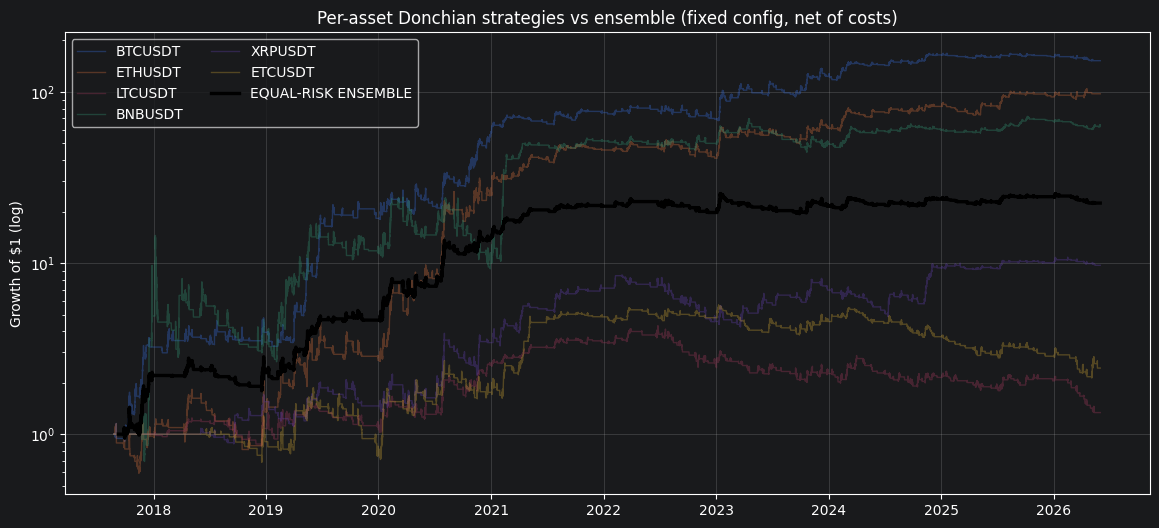

In [9]:
eq = (1 + ret_panel.fillna(0)).cumprod()
port_eq = (1 + eq_risk_ret).cumprod()
plt.figure(figsize=(14, 6))
for sym in ret_panel.columns:
    plt.plot(eq.index, eq[sym], alpha=0.35, linewidth=1, label=sym)
plt.plot(port_eq.index, port_eq.values, color="black", linewidth=2.4, label="EQUAL-RISK ENSEMBLE")
plt.yscale("log")
plt.title("Per-asset Donchian strategies vs ensemble (fixed config, net of costs)")
plt.ylabel("Growth of $1 (log)"); plt.legend(ncol=2); plt.grid(True, alpha=0.3); plt.show()

## 4b. Full performance metrics
Total & annualized return, volatility, Sharpe, Sortino, max drawdown, Calmar, profit factor and
win rate — for every single coin and for both ensembles, side by side.

In [10]:
def full_metrics(returns, periods=HOURS_PER_YEAR):
    """Comprehensive performance summary from a periodic (hourly) return series."""
    r = pd.Series(returns).dropna()
    if len(r) < 2 or r.std() == 0:
        return {}
    equity   = (1 + r).cumprod()
    total    = float(equity.iloc[-1] - 1)
    years    = len(r) / periods
    cagr     = (1 + total) ** (1 / years) - 1
    ann_vol  = r.std() * np.sqrt(periods)
    shp      = sharpe_ratio(r, periods)
    downside = r[r < 0].std() * np.sqrt(periods)
    sortino  = (r.mean() * periods) / downside if downside > 0 else np.nan
    mdd      = max_drawdown(equity)
    calmar   = cagr / abs(mdd) if mdd < 0 else np.nan
    gp, gl   = r[r > 0].sum(), abs(r[r < 0].sum())
    pf       = gp / gl if gl > 0 else np.inf
    return {
        "Total Return":       round(total, 4),
        "Ann. Return (CAGR)": round(cagr, 4),
        "Ann. Volatility":    round(ann_vol, 4),
        "Sharpe":             round(shp, 3),
        "Sortino":            round(sortino, 3),
        "Max Drawdown":       round(mdd, 4),
        "Calmar":             round(calmar, 3),
        "Profit Factor":      round(pf, 3),
        "Win Rate":           round(float((r > 0).mean()), 4),
        "Best Hour":          round(float(r.max()), 4),
        "Worst Hour":         round(float(r.min()), 4),
    }


rows = []
for sym in ret_panel.columns:
    rows.append({"Strategy": sym, **full_metrics(per_asset[sym])})
rows.append({"Strategy": "Equal-Weight Ensemble", **full_metrics(eq_weight_ret)})
rows.append({"Strategy": "Equal-Risk Ensemble",   **full_metrics(eq_risk_ret)})

metrics_table = pd.DataFrame(rows).set_index("Strategy")
metrics_table

,Total Return,Ann. Return (CAGR),Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Profit Factor,Win Rate,Best Hour,Worst Hour
Strategy,,,,,,,,,,,
BTCUSDT,151.2901,0.7752,0.4416,1.521,0.940,-0.3182,2.436,1.125,0.1421,0.2119,-0.1540
ETHUSDT,96.5397,0.6871,0.5864,1.186,0.745,-0.5565,1.235,1.096,0.1399,0.2125,-0.2631
LTCUSDT,0.3362,0.0350,0.3872,0.283,0.174,-0.6884,0.051,1.020,0.1124,0.1044,-0.1826
BNBUSDT,62.6350,0.6267,0.8304,0.999,0.608,-0.8172,0.767,1.092,0.1329,0.3889,-0.3043
XRPUSDT,8.6974,0.3261,0.3964,0.909,0.537,-0.5036,0.648,1.077,0.0977,0.1182,-0.1133
ETCUSDT,1.4325,0.1184,0.4787,0.473,0.282,-0.6253,0.189,1.039,0.0992,0.1382,-0.2257
Equal-Weight Ensemble,67.0660,0.6178,0.3841,1.446,1.118,-0.3100,1.993,1.093,0.2565,0.0969,-0.1697
Equal-Risk Ensemble,21.4110,0.4354,0.3117,1.316,0.880,-0.3562,1.222,1.100,0.1997,0.0974,-0.1379


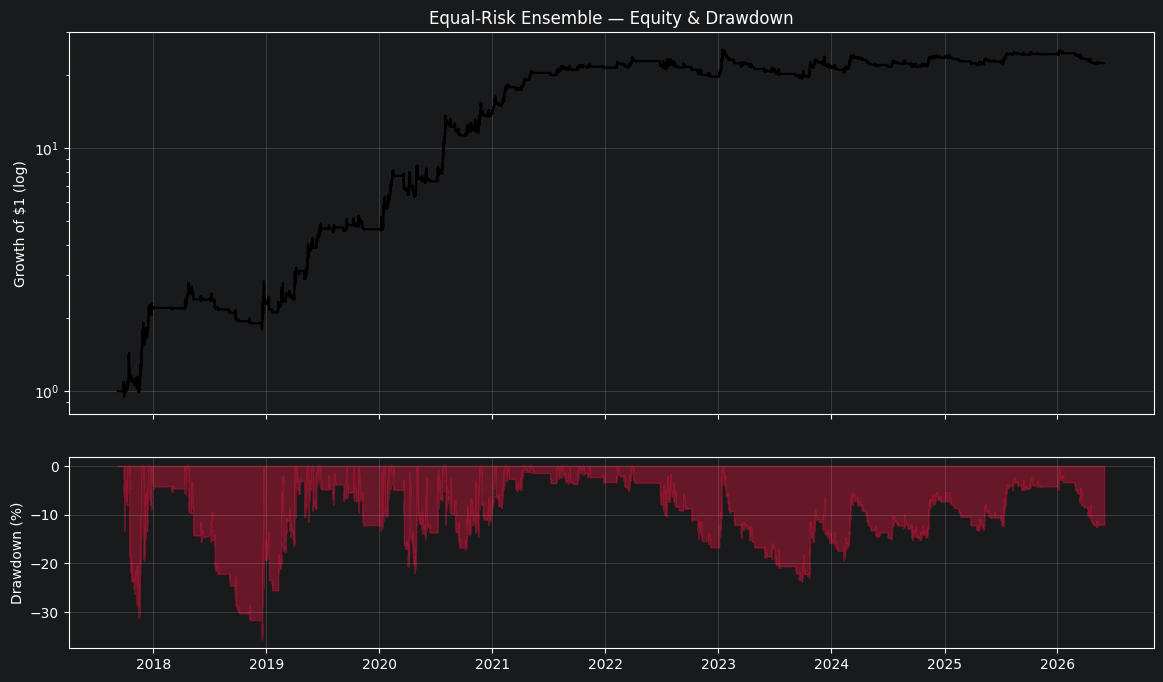

Max drawdown: -35.6%


In [11]:
# Drawdown plot — robust (no tight_layout; tz-safe even if an index slips through)
_eq = (1 + eq_risk_ret.dropna()).cumprod()
_dd = (_eq / _eq.cummax() - 1) * 100
if getattr(_eq.index, "tz", None) is not None:
    _eq.index = _eq.index.tz_localize(None)
    _dd.index = _dd.index.tz_localize(None)

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(_eq.index, _eq.values, color="black", linewidth=1.6)
ax[0].set_yscale("log"); ax[0].set_ylabel("Growth of $1 (log)")
ax[0].set_title("Equal-Risk Ensemble — Equity & Drawdown"); ax[0].grid(True, alpha=0.3)
ax[1].fill_between(_dd.index, _dd.values, 0, color="crimson", alpha=0.4)
ax[1].set_ylabel("Drawdown (%)"); ax[1].grid(True, alpha=0.3)
fig.subplots_adjust(hspace=0.15)
plt.show()
print(f"Max drawdown: {_dd.min():.1f}%")


## 4c. True walk-forward test (rolling re-optimization)

This is a *genuine* walk-forward, not the fixed-config evaluation above. For each rolling window it:
1. takes a **1-year training slice** and re-optimizes a **small 3-parameter set** (entry lookback, exit
   lookback, ADX threshold) with Optuna — shared across the whole basket so it fits less noise than
   per-asset tuning;
2. **freezes** those parameters;
3. tests them on the next **3-month** slice the optimizer never saw (with a warm-up buffer so the
   channels aren't empty at the window start);
4. advances and repeats, then stitches all the out-of-sample slices into the portfolio.

**This is slow** (Optuna × windows × assets, each a Python-loop backtest) — expect several minutes.
Lower `n_trials` to 15 for a quick pass.

**What to watch for:** this walk-forward number will likely come out *lower* than the fixed-config
ensemble Sharpe. If it does, that's informative — it means per-window optimization is partly fitting
noise, and the fixed-config result (which fits nothing) is the more trustworthy one. Re-optimization
is not automatically "better"; here it's a stress test.

In [12]:
import sys, subprocess
try:
    import optuna
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# everything except the 3 optimized knobs is held fixed
CORE_FIXED = dict(ema_period=200, use_adx_filter=True, use_vol_confirm=True, vol_ma_mult=1.2,
                  use_atr_sizing=True, stop_atr_mult=2.5, take_profit=0.40,
                  max_hold=24*21, cost_bps=5, long_short=False)

def wf_objective(train_slices):
    # maximize the MEAN Sharpe across all assets in the training window
    def obj(trial):
        p = dict(entry_lookback=trial.suggest_int("entry_lookback", 48, 400, step=24),
                 exit_lookback =trial.suggest_int("exit_lookback",  24, 200, step=24),
                 adx_threshold =trial.suggest_float("adx_threshold", 18, 30),
                 **CORE_FIXED)
        if p["exit_lookback"] > p["entry_lookback"]:
            return -999.0
        sharpes = []
        for tdf in train_slices.values():
            try:
                res = improved_donchian_strategy(tdf, **p)
                s = sharpe_ratio(res["Strategy_Return"])
                if res["Trade"].sum() < 5:    # discourage degenerate no-trade configs
                    s -= 1.0
                if np.isfinite(s):
                    sharpes.append(s)
            except Exception:
                pass
        return float(np.mean(sharpes)) if sharpes else -999.0
    return obj


def walk_forward_ensemble(asset_data, train_size=24*365, test_size=24*90,
                          n_trials=30, seed=42, min_train_rows=24*120):
    ref_index = max(asset_data.values(), key=len).index   # longest series = calendar clock
    n = len(ref_index)
    oos_chunks = {}   # sym -> list of OOS Strategy_Return slices
    window_log = []
    start, wnum = 0, 1

    while start + train_size + test_size <= n:
        train_lo, train_hi = ref_index[start], ref_index[start + train_size - 1]
        test_lo,  test_hi  = ref_index[start + train_size], ref_index[start + train_size + test_size - 1]

        train_slices = {sym: d.loc[train_lo:train_hi] for sym, d in asset_data.items()}
        train_slices = {s: sl for s, sl in train_slices.items() if len(sl) >= min_train_rows}
        if not train_slices:
            start += test_size; wnum += 1; continue

        study = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=seed + wnum))
        study.optimize(wf_objective(train_slices), n_trials=n_trials, show_progress_bar=False)
        p = {**study.best_params, **CORE_FIXED}
        if p["exit_lookback"] > p["entry_lookback"]:
            p["exit_lookback"] = p["entry_lookback"] // 2

        warm = pd.Timedelta(hours=max(p["entry_lookback"], 200) + 40)
        for sym, d in asset_data.items():
            test_mask = (d.index >= test_lo) & (d.index <= test_hi)
            if test_mask.sum() < 24:
                continue
            run_sl = d.loc[test_lo - warm : test_hi]            # warm-up buffer + test slice
            res = improved_donchian_strategy(run_sl, **p)
            oos = res["Strategy_Return"].loc[(res.index >= test_lo) & (res.index <= test_hi)]
            oos_chunks.setdefault(sym, []).append(oos)

        window_log.append({"window": wnum, "test_start": str(test_lo.date()), "test_end": str(test_hi.date()),
                           "entry_lookback": p["entry_lookback"], "exit_lookback": p["exit_lookback"],
                           "adx_threshold": round(p["adx_threshold"], 1)})
        print(f"  win {wnum:2d}: test {test_lo.date()} -> {test_hi.date()}   "
              f"entry={p['entry_lookback']}  exit={p['exit_lookback']}  adx={p['adx_threshold']:.1f}")
        start += test_size; wnum += 1

    per_asset_oos = {s: pd.concat(c).sort_index() for s, c in oos_chunks.items()}
    wf_panel = pd.DataFrame(per_asset_oos).sort_index()
    vol = wf_panel.rolling(24*14).std().shift(1)
    w = (1.0/vol).div((1.0/vol).sum(axis=1), axis=0)
    wf_port = (wf_panel * w).sum(axis=1, min_count=1).dropna()       # equal-risk
    wf_ew   = wf_panel.mean(axis=1, skipna=True).dropna()            # equal-weight
    return wf_port, wf_ew, wf_panel, pd.DataFrame(window_log)

In [13]:
print("Running TRUE walk-forward (this takes a few minutes)...\n")
wf_port, wf_ew, wf_panel, wf_log = walk_forward_ensemble(
    asset_data, train_size=24*365, test_size=24*90, n_trials=30, seed=42)

print("\n===== TRUE WALK-FORWARD RESULTS (rolling re-optimization) =====")
print(f"Windows completed       : {len(wf_log)}")
print(f"WF equal-risk  Sharpe   : {round(sharpe_ratio(wf_port), 3)}")
print(f"WF equal-weight Sharpe  : {round(sharpe_ratio(wf_ew), 3)}")

print("\nFull metrics (WF equal-risk ensemble):")
for k, v in full_metrics(wf_port).items():
    print(f"  {k:20s}: {v}")

print("\nRe-optimized parameters per window:")
print(wf_log.to_string(index=False))

print("\nWalk-forward per-quarter Sharpe:")
print(per_period_sharpe(wf_port).to_string(index=False))

print("\nCompare: fixed-config equal-risk Sharpe was "
      f"{round(sharpe_ratio(eq_risk_ret), 3)}.")
print("If the walk-forward Sharpe is lower, per-window optimization is fitting noise — "
      "the fixed-config number is then the more reliable estimate.")

Running TRUE walk-forward (this takes a few minutes)...

  win  1: test 2018-08-20 -> 2018-11-19   entry=288  exit=144  adx=23.2
  win  2: test 2018-11-19 -> 2019-02-17   entry=360  exit=24  adx=22.7
  win  3: test 2019-02-17 -> 2019-05-18   entry=48  exit=48  adx=19.4
  win  4: test 2019-05-18 -> 2019-08-17   entry=96  exit=96  adx=27.3
  win  5: test 2019-08-17 -> 2019-11-15   entry=96  exit=72  adx=27.7
  win  6: test 2019-11-15 -> 2020-02-13   entry=120  exit=72  adx=18.5
  win  7: test 2020-02-13 -> 2020-05-13   entry=96  exit=96  adx=21.0
  win  8: test 2020-05-13 -> 2020-08-11   entry=96  exit=48  adx=20.1
  win  9: test 2020-08-11 -> 2020-11-09   entry=72  exit=48  adx=20.1
  win 10: test 2020-11-09 -> 2021-02-08   entry=72  exit=72  adx=23.0
  win 11: test 2021-02-08 -> 2021-05-09   entry=216  exit=96  adx=24.3
  win 12: test 2021-05-09 -> 2021-08-07   entry=144  exit=72  adx=24.6
  win 13: test 2021-08-07 -> 2021-11-05   entry=120  exit=96  adx=20.7
  win 14: test 2021-11-05 

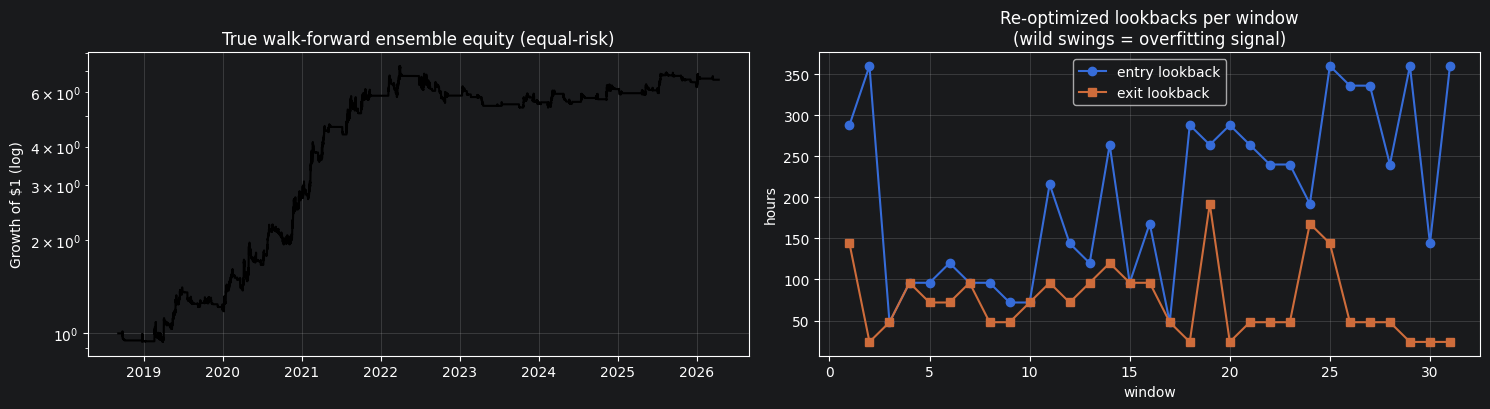

In [14]:
wf_eq = (1 + wf_port).cumprod()
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
ax[0].plot(wf_eq.index, wf_eq.values, color="black", linewidth=1.5)
ax[0].set_yscale("log"); ax[0].set_title("True walk-forward ensemble equity (equal-risk)")
ax[0].set_ylabel("Growth of $1 (log)"); ax[0].grid(True, alpha=0.3)
ax[1].plot(wf_log["window"], wf_log["entry_lookback"], marker="o", label="entry lookback")
ax[1].plot(wf_log["window"], wf_log["exit_lookback"],  marker="s", label="exit lookback")
ax[1].set_title("Re-optimized lookbacks per window\n(wild swings = overfitting signal)")
ax[1].set_xlabel("window"); ax[1].set_ylabel("hours"); ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
CORE_FIXED = dict(ema_period=200, use_adx_filter=True, use_vol_confirm=True, vol_ma_mult=1.2,
                  use_atr_sizing=True, stop_atr_mult=2.5, take_profit=0.40,
                  max_hold=24*21, cost_bps=5, long_short=False)

def insample_obj(trial):
    p = dict(entry_lookback=trial.suggest_int("entry_lookback", 48, 400, step=24),
             exit_lookback =trial.suggest_int("exit_lookback",  24, 200, step=24),
             adx_threshold =trial.suggest_float("adx_threshold", 18, 30), **CORE_FIXED)
    if p["exit_lookback"] > p["entry_lookback"]: return -999.0
    panel = pd.DataFrame({s: improved_donchian_strategy(d, **p)["Strategy_Return"]
                          for s, d in asset_data.items()}).sort_index()
    return sharpe_ratio(panel.mean(axis=1, skipna=True).dropna())   # equal-weight ensemble

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(insample_obj, n_trials=30)   # lower to ~15 / fewer coins if slow
print("Best IN-SAMPLE params:", study.best_params)
print("Best IN-SAMPLE equal-weight Sharpe:", round(study.best_value, 3))
print("vs. fixed-config (no fit) equal-weight Sharpe: 1.446")

Best IN-SAMPLE params: {'entry_lookback': 72, 'exit_lookback': 48, 'adx_threshold': 23.63458589491965}
Best IN-SAMPLE equal-weight Sharpe: 1.603
vs. fixed-config (no fit) equal-weight Sharpe: 1.446


In [16]:
best = dict(**study.best_params, **CORE_FIXED)
panel = pd.DataFrame({s: improved_donchian_strategy(d, **best)["Strategy_Return"]
                      for s, d in asset_data.items()}).sort_index()
ew_best = panel.mean(axis=1, skipna=True).dropna()
m = full_metrics(ew_best)
print("IN-SAMPLE (full-history optimized) equal-weight ensemble:")
print(f"  Ann. Return (CAGR): {m['Ann. Return (CAGR)']*100:.1f}%")
print(f"  Total Return      : {m['Total Return']:.1f}x")
print(f"  Sharpe            : {m['Sharpe']}")
print(f"  Max Drawdown      : {m['Max Drawdown']*100:.1f}%")
print("vs. fixed-config (no fit): CAGR 61.8%, Sharpe 1.45, MaxDD -31.0%")

IN-SAMPLE (full-history optimized) equal-weight ensemble:
  Ann. Return (CAGR): 77.7%
  Total Return      : 155.0x
  Sharpe            : 1.603
  Max Drawdown      : -32.4%
vs. fixed-config (no fit): CAGR 61.8%, Sharpe 1.45, MaxDD -31.0%


In [17]:
print("Best IN-SAMPLE equal-weight Sharpe:", round(study.best_value, 3))

Best IN-SAMPLE equal-weight Sharpe: 1.603


In [18]:
full_metrics(wf_ew)

{'Total Return': 21.0296,
 'Ann. Return (CAGR)': 0.4986,
 'Ann. Volatility': np.float64(0.2578),
 'Sharpe': np.float64(1.699),
 'Sortino': np.float64(1.355),
 'Max Drawdown': -0.2721,
 'Calmar': 1.832,
 'Profit Factor': np.float64(1.099),
 'Win Rate': 0.2402,
 'Best Hour': 0.0584,
 'Worst Hour': -0.104}

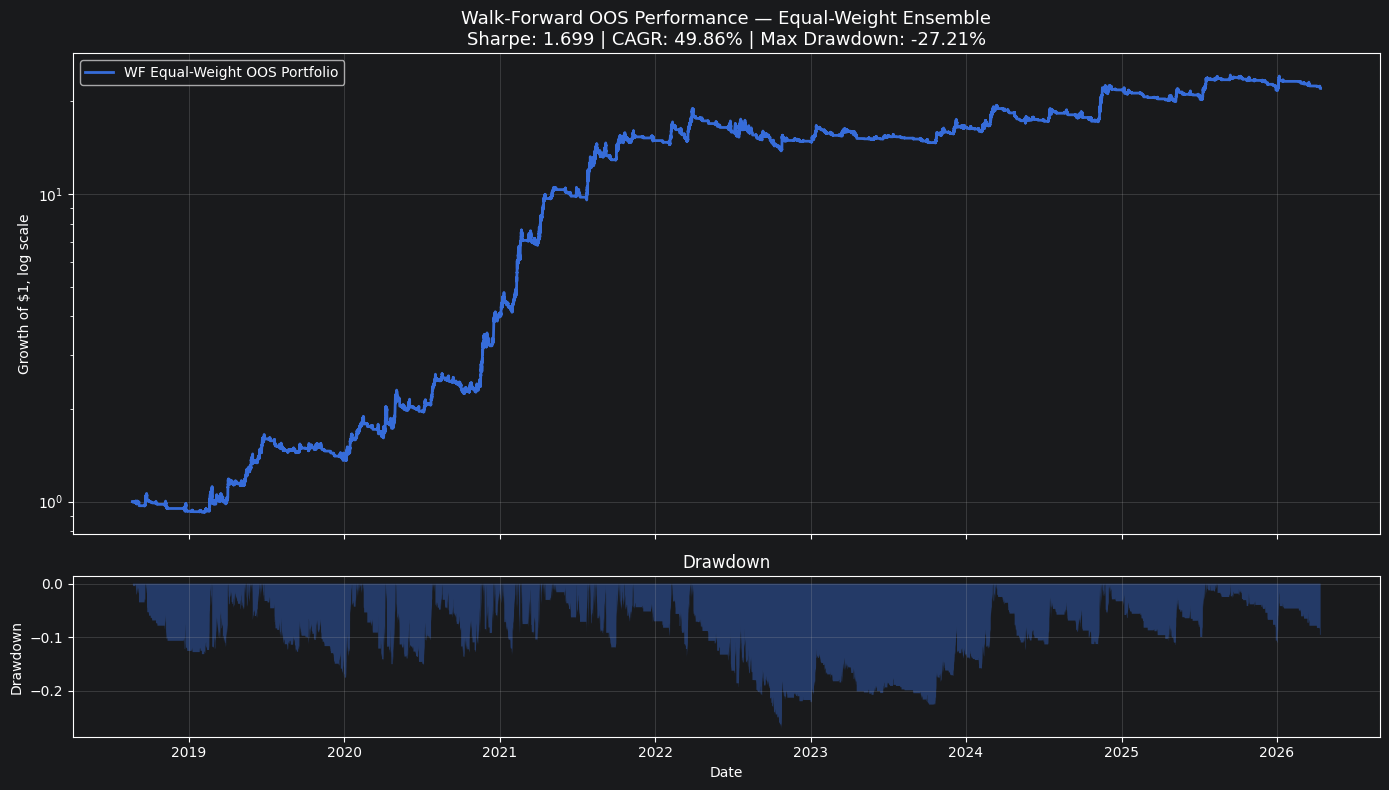

In [19]:
# ============================================================
# PLOT WALK-FORWARD OOS EQUAL-WEIGHT PERFORMANCE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check that wf_ew exists
if "wf_ew" not in globals():
    raise NameError(
        "wf_ew is not defined. Run the walk-forward ensemble cell first. "
        "That cell should create wf_port, wf_ew, wf_panel, and wf_log."
    )

# Clean OOS equal-weight returns
wf_ew_clean = wf_ew.copy()
wf_ew_clean = wf_ew_clean.replace([np.inf, -np.inf], np.nan).dropna()

# Equity curve
wf_ew_equity = (1 + wf_ew_clean).cumprod()

# Drawdown
wf_ew_drawdown = wf_ew_equity / wf_ew_equity.cummax() - 1

# Metrics
wf_ew_metrics = full_metrics(wf_ew_clean)

sharpe = wf_ew_metrics["Sharpe"]
cagr = wf_ew_metrics["Ann. Return (CAGR)"]
maxdd = wf_ew_metrics["Max Drawdown"]

# Plot
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# Equity curve
axes[0].plot(
    wf_ew_equity.index,
    wf_ew_equity.values,
    linewidth=2,
    label="WF Equal-Weight OOS Portfolio"
)

axes[0].set_yscale("log")
axes[0].set_title(
    f"Walk-Forward OOS Performance — Equal-Weight Ensemble\n"
    f"Sharpe: {sharpe:.3f} | CAGR: {cagr:.2%} | Max Drawdown: {maxdd:.2%}",
    fontsize=13
)
axes[0].set_ylabel("Growth of $1, log scale")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Drawdown
axes[1].fill_between(
    wf_ew_drawdown.index,
    wf_ew_drawdown.values,
    0,
    alpha=0.4
)

axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()